# Retail Sales Analytics Using Python

### Major Data Analytics Project

**Domain:** Retail  
**Focus:** Sales performance, product performance, customer purchasing patterns, geographic performance, and sales trends  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

---

## Project Overview

This project analyzes retail transaction data to understand sales performance and identify meaningful patterns in products, customers, countries, and sales trends.

The analysis involves data loading, data cleaning, exploratory data analysis, statistical analysis, visualization, and business insight generation.

The objective is to transform raw retail transaction data into meaningful information that can support data-driven business decisions.

In [1]:
# ── Section 0: Import Required Libraries ───────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All required libraries imported successfully.")

All required libraries imported successfully.


## 1. Problem Statement

Retail businesses generate large volumes of transaction data containing information about products, quantities, prices, customers, dates, and locations. Raw transaction data alone does not directly reveal important patterns in sales performance or customer purchasing behavior.

The purpose of this project is to analyze retail sales transaction data and identify meaningful patterns, trends, relationships, and variations in sales performance.

The analysis focuses on understanding sales trends over time, product performance, customer purchasing patterns, geographic performance, and important factors affecting overall sales.

The findings will be used to generate evidence-based business insights and recommendations.

## 2. Objectives

- Understand the structure and quality of the retail sales dataset.
- Clean and prepare the transaction data for analysis.
- Analyze overall sales performance.
- Examine sales trends over time.
- Identify top-performing and low-performing products.
- Analyze customer purchasing patterns.
- Compare sales performance across countries.
- Examine relationships between important sales variables.
- Create meaningful visualizations for retail sales analysis.
- Generate business insights from the analytical results.
- Provide practical recommendations based on the findings.

## 3. Dataset Loading

The project uses the UCI Online Retail dataset for retail transaction analysis.

The dataset is downloaded automatically from the official UCI Machine Learning Repository and extracted into the project `data` folder. This approach avoids requiring manual dataset uploads when running the notebook in a fresh Google Colab environment.

In [2]:
# ── Section 3: Load Dataset ────────────────────────────────────────────────

import os
import zipfile
import urllib.request
import pandas as pd

# Create data directories
os.makedirs("data", exist_ok=True)
os.makedirs("data/uci_dataset", exist_ok=True)

# UCI Online Retail dataset
ZIP_URL = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
ZIP_FILE = "data/online_retail.zip"
EXTRACT_FOLDER = "data/uci_dataset"
EXCEL_FILE = "data/uci_dataset/Online Retail.xlsx"

# Download and extract dataset if it is not already available
if not os.path.exists(EXCEL_FILE):
    print("Downloading Online Retail dataset from UCI...")

    urllib.request.urlretrieve(ZIP_URL, ZIP_FILE)

    print("Extracting dataset...")

    with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_FOLDER)

    print("Dataset downloaded and extracted successfully.")

# Load dataset
df = pd.read_excel(EXCEL_FILE)

print(f"Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
df.head()

Dataset loaded successfully: 541,909 rows × 8 columns

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 4. Initial Dataset Inspection

Before performing data cleaning, the dataset is inspected to understand its structure, data types, missing values, duplicate records, and basic statistical characteristics.

In [3]:
# ── Section 4.1: Dataset Structure and Data Types ─────────────────────────

print("Dataset information:")
print(df.info())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None


In [4]:
# ── Section 4.2: Missing Values ────────────────────────────────────────────

print("Missing values in each column:")
print(df.isnull().sum())

print("\nMissing-value percentage:")
print((df.isnull().mean() * 100).round(2))

Missing values in each column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing-value percentage:
InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64


In [5]:
# ── Section 4.3: Duplicate Records ─────────────────────────────────────────

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate records: {duplicate_count:,}")

Number of duplicate records: 5,268


In [6]:
# ── Section 4.4: Descriptive Statistics ────────────────────────────────────

print("Descriptive statistics for numerical columns:")
df.describe()

Descriptive statistics for numerical columns:


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
# ── Section 4.5: Unique Values ─────────────────────────────────────────────

print("Number of unique values in each column:")
print(df.nunique())

Number of unique values in each column:
InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64


## 5. Data Cleaning and Preparation

The raw retail transaction dataset contains missing values, duplicate records, cancellation transactions, and non-positive quantity or price values.

The data cleaning process removes exact duplicate records, handles missing product descriptions, identifies cancelled invoices, and retains valid sales transactions for revenue analysis.

A cleaned dataset is created for the subsequent exploratory and business analysis.

In [8]:
# ── Section 5.1: Create Working Copy ───────────────────────────────────────

df_clean = df.copy()

print(f"Original dataset size: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

Original dataset size: 541,909 rows × 8 columns


In [9]:
# ── Section 5.2: Remove Duplicate Records ──────────────────────────────────

duplicates_before = df_clean.duplicated().sum()

df_clean = df_clean.drop_duplicates().copy()

print(f"Duplicate records identified: {duplicates_before:,}")
print(f"Dataset size after removing duplicates: {df_clean.shape[0]:,} rows")

Duplicate records identified: 5,268
Dataset size after removing duplicates: 536,641 rows


In [10]:
# ── Section 5.3: Handle Missing Product Descriptions ───────────────────────

missing_description_before = df_clean["Description"].isna().sum()

df_clean = df_clean.dropna(subset=["Description"]).copy()

print(f"Rows with missing Description removed: {missing_description_before:,}")
print(f"Dataset size after removing missing descriptions: {df_clean.shape[0]:,} rows")

Rows with missing Description removed: 1,454
Dataset size after removing missing descriptions: 535,187 rows


In [11]:
# ── Section 5.4: Identify Cancelled Transactions ──────────────────────────

df_clean["IsCancelled"] = df_clean["InvoiceNo"].astype(str).str.startswith("C")

cancelled_count = df_clean["IsCancelled"].sum()

print(f"Cancelled transaction rows identified: {cancelled_count:,}")
print(f"Normal transaction rows: {(~df_clean['IsCancelled']).sum():,}")

Cancelled transaction rows identified: 9,251
Normal transaction rows: 525,936


In [12]:
# ── Section 5.5: Create Valid Sales Dataset ────────────────────────────────

df_sales = df_clean[
    (~df_clean["IsCancelled"]) &
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
].copy()

print(f"Valid sales transactions: {df_sales.shape[0]:,} rows")

Valid sales transactions: 524,878 rows


In [13]:
# ── Section 5.6: Calculate Revenue ─────────────────────────────────────────

df_sales["Revenue"] = df_sales["Quantity"] * df_sales["UnitPrice"]

print("Revenue column created successfully.")

print("\nSample revenue calculations:")
df_sales[["Quantity", "UnitPrice", "Revenue"]].head()

Revenue column created successfully.

Sample revenue calculations:


,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [14]:
# ── Section 5.7: Verify Cleaned Dataset ────────────────────────────────────

print("Cleaned dataset information:")
print(df_sales.info())

print("\nRemaining missing values:")
print(df_sales.isnull().sum())

print("\nFinal dataset size:")
print(f"{df_sales.shape[0]:,} rows × {df_sales.shape[1]} columns")

print("\nRevenue statistics:")
print(df_sales["Revenue"].describe())

Cleaned dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 524878 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      524878 non-null  object        
 8   IsCancelled  524878 non-null  bool          
 9   Revenue      524878 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 40.5+ MB
None

Remaining missing values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID

## 6. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand sales patterns, product performance, customer activity, geographic distribution, and changes in revenue over time.

Additional date-based features are created to support monthly, daily, and yearly sales analysis.

In [15]:
# ── Section 6.1: Create Date Features ──────────────────────────────────────

df_sales["Year"] = df_sales["InvoiceDate"].dt.year
df_sales["Month"] = df_sales["InvoiceDate"].dt.month
df_sales["MonthName"] = df_sales["InvoiceDate"].dt.month_name()
df_sales["DayOfWeek"] = df_sales["InvoiceDate"].dt.day_name()
df_sales["Date"] = df_sales["InvoiceDate"].dt.date

print("Date features created successfully.")

print("\nNew date-related columns:")
print(["Year", "Month", "MonthName", "DayOfWeek", "Date"])

Date features created successfully.

New date-related columns:
['Year', 'Month', 'MonthName', 'DayOfWeek', 'Date']


In [16]:
# ── Section 6.2: Verify Date Features ──────────────────────────────────────

df_sales[
    [
        "InvoiceDate",
        "Year",
        "Month",
        "MonthName",
        "DayOfWeek",
        "Date"
    ]
].head()

,InvoiceDate,Year,Month,MonthName,DayOfWeek,Date
0,2010-12-01 08:26:00,2010,12,December,Wednesday,2010-12-01
1,2010-12-01 08:26:00,2010,12,December,Wednesday,2010-12-01
2,2010-12-01 08:26:00,2010,12,December,Wednesday,2010-12-01
3,2010-12-01 08:26:00,2010,12,December,Wednesday,2010-12-01
4,2010-12-01 08:26:00,2010,12,December,Wednesday,2010-12-01


### 6.3 Monthly Revenue Trend

Monthly revenue is analyzed to identify changes in sales performance over the study period and observe periods of relatively higher or lower revenue.

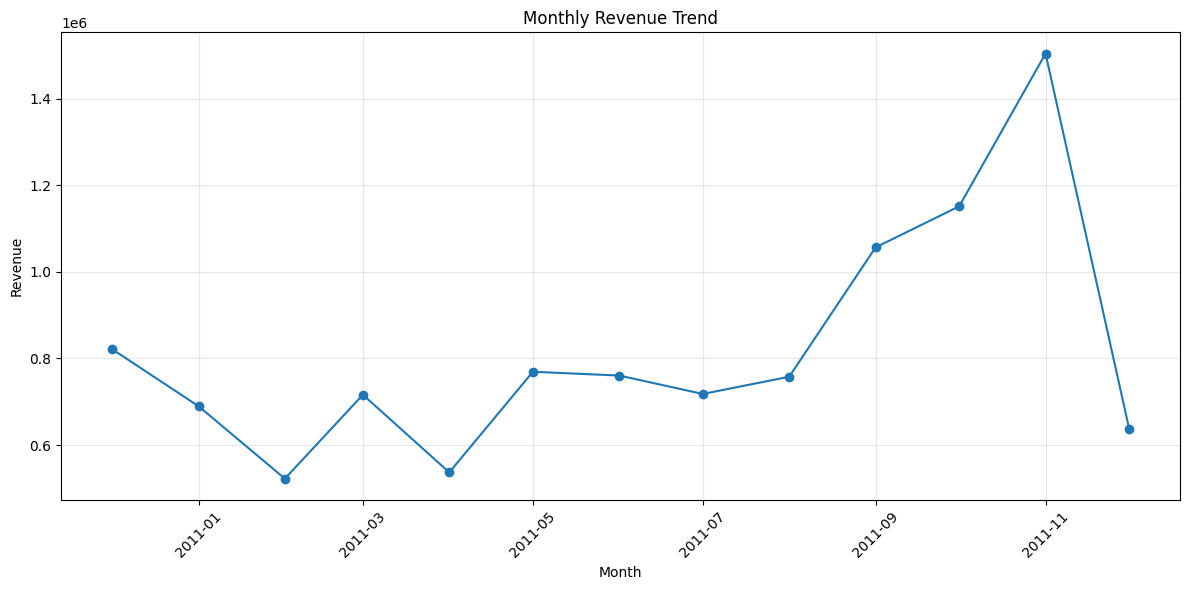

In [17]:
# ── Section 6.3: Monthly Revenue Trend ─────────────────────────────────────

monthly_revenue = (
    df_sales
    .groupby(["Year", "Month"], as_index=False)["Revenue"]
    .sum()
)

monthly_revenue["YearMonth"] = pd.to_datetime(
    monthly_revenue["Year"].astype(str) + "-" +
    monthly_revenue["Month"].astype(str) + "-01"
)

monthly_revenue = monthly_revenue.sort_values("YearMonth")

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Top 10 Countries by Revenue

Country-level revenue is analyzed to identify the geographic markets that contributed the highest sales revenue during the study period.

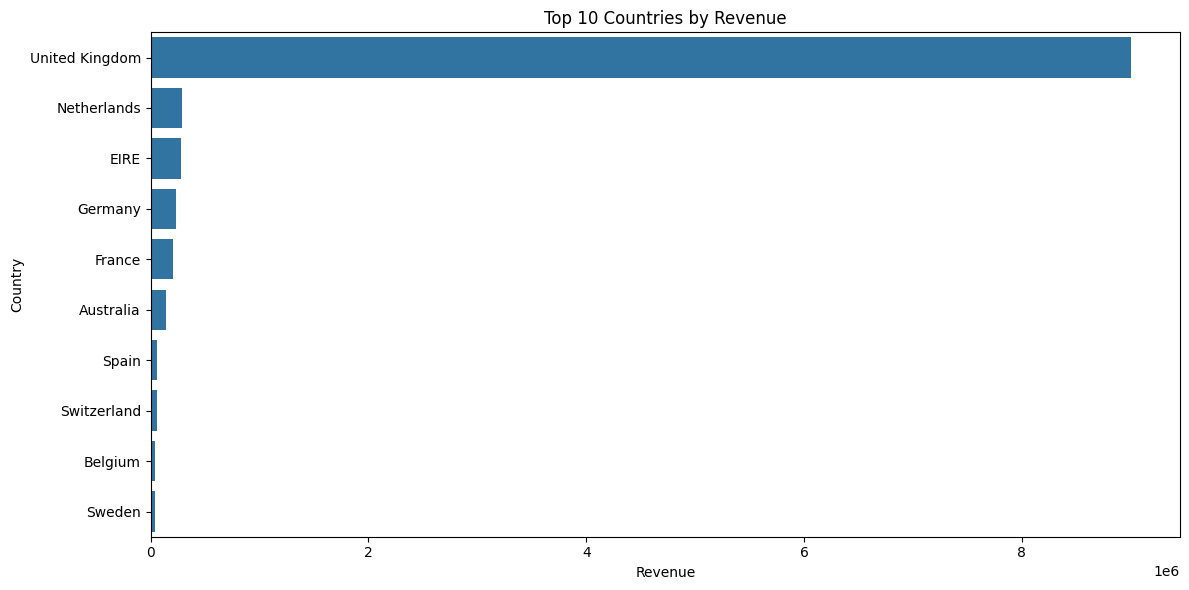

In [18]:
# ── Section 6.4: Top 10 Countries by Revenue ───────────────────────────────

country_revenue = (
    df_sales
    .groupby("Country", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
)

top_10_countries = country_revenue.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_countries,
    x="Revenue",
    y="Country"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

### 6.5 Top 10 Products by Revenue

Product-level revenue is analyzed to identify the products that generated the highest total sales revenue during the study period.

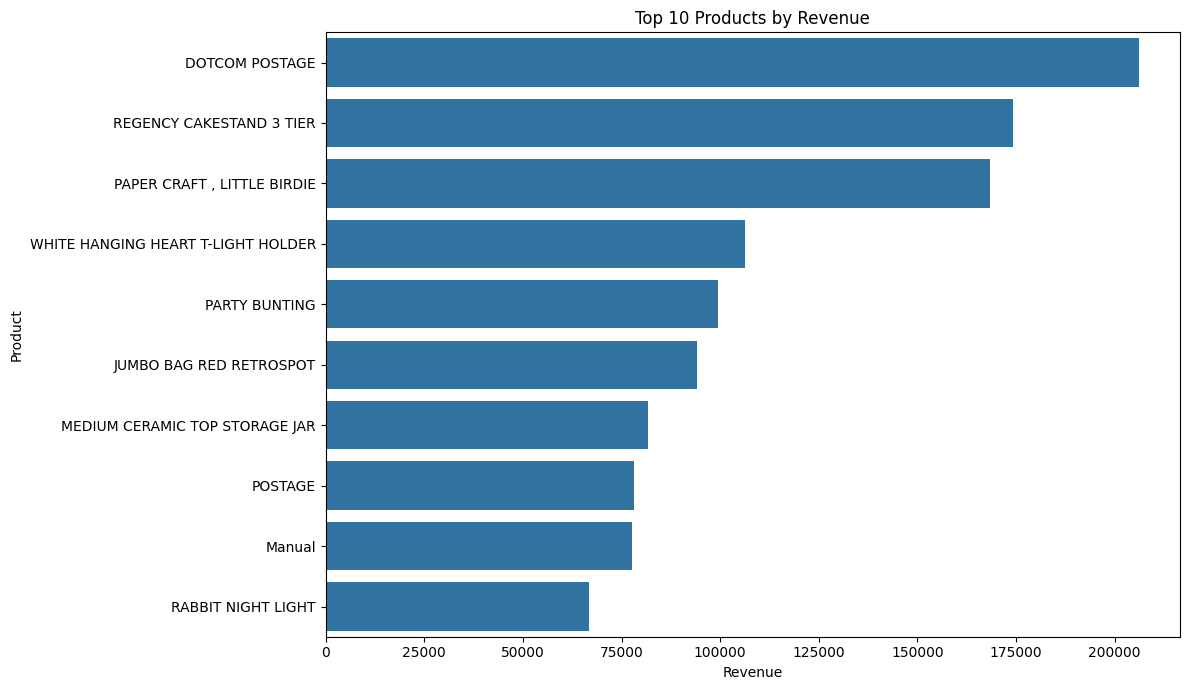

In [19]:
# ── Section 6.5: Top 10 Products by Revenue ────────────────────────────────

product_revenue = (
    df_sales
    .groupby("Description", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
)

top_10_products = product_revenue.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_10_products,
    x="Revenue",
    y="Description"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### 6.6 Top 10 Products by Quantity Sold

Product-level quantity analysis is performed to identify the products with the highest number of units sold during the study period.

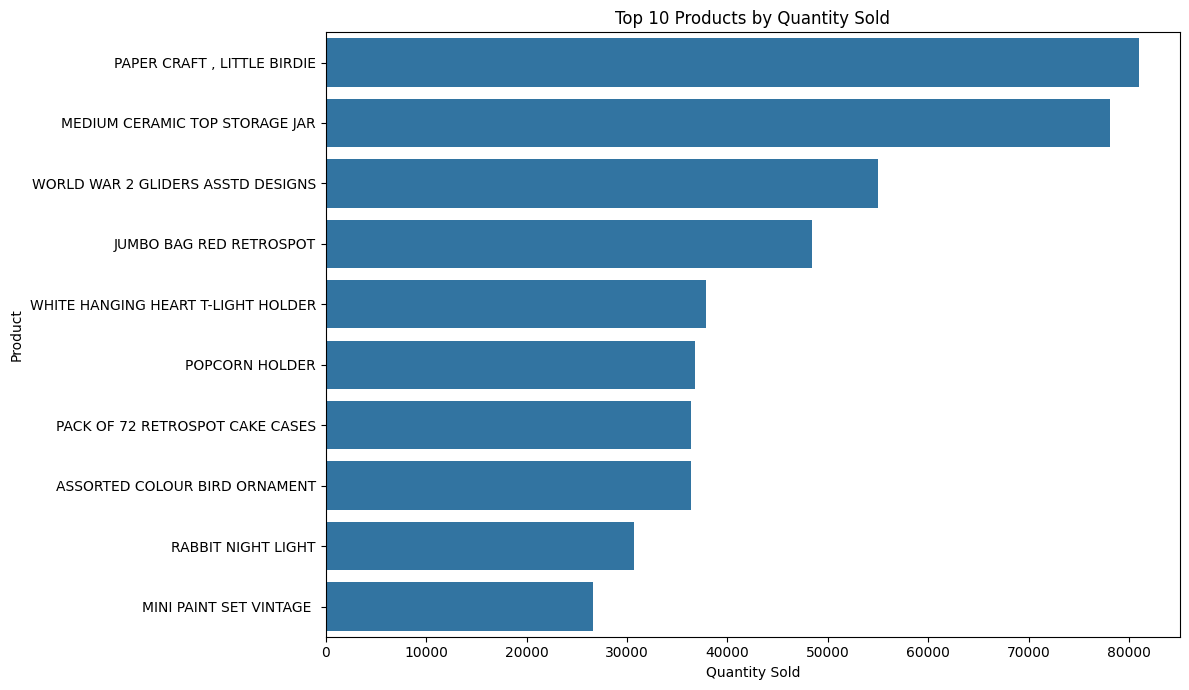

In [20]:
# ── Section 6.6: Top 10 Products by Quantity Sold ──────────────────────────

product_quantity = (
    df_sales
    .groupby("Description", as_index=False)["Quantity"]
    .sum()
    .sort_values("Quantity", ascending=False)
)

top_10_quantity_products = product_quantity.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_10_quantity_products,
    x="Quantity",
    y="Description"
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

### 6.7 Customer Sales Analysis

Customer-level revenue is analyzed using transactions with available CustomerID values. The analysis identifies customers who contributed the highest total revenue during the study period.

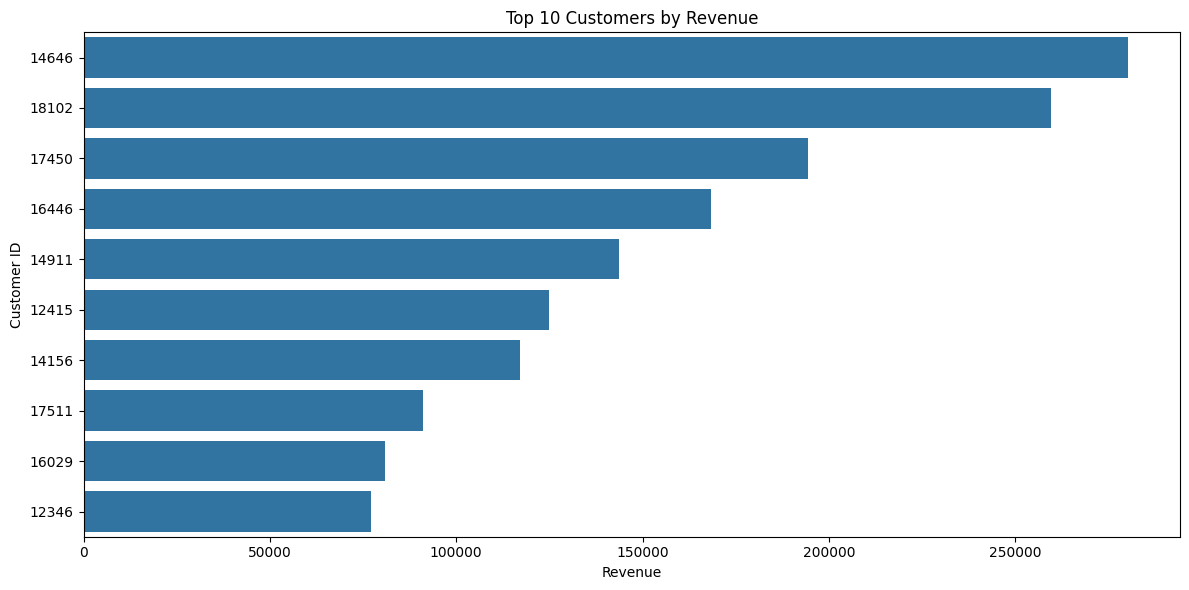

In [21]:
# ── Section 6.7: Top 10 Customers by Revenue ───────────────────────────────

customer_revenue = (
    df_sales
    .dropna(subset=["CustomerID"])
    .groupby("CustomerID", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
)

top_10_customers = customer_revenue.head(10).copy()

# Convert CustomerID to categorical text for visualization
top_10_customers["CustomerID"] = (
    top_10_customers["CustomerID"]
    .astype(int)
    .astype(str)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_customers,
    x="Revenue",
    y="CustomerID"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

### 6.8 Monthly Quantity and Revenue Comparison

Monthly sales quantity and revenue are compared to examine changes in sales volume and their relationship with revenue over time.

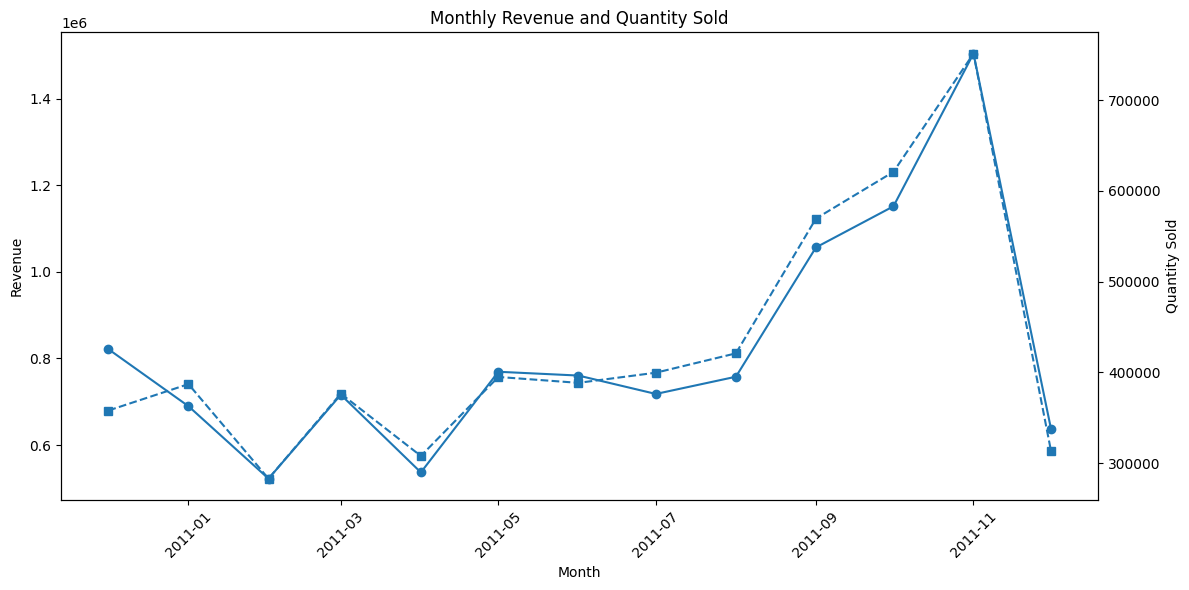

In [22]:
# ── Section 6.8: Monthly Quantity and Revenue Comparison ───────────────────

monthly_sales = (
    df_sales
    .groupby(["Year", "Month"], as_index=False)
    .agg(
        TotalQuantity=("Quantity", "sum"),
        TotalRevenue=("Revenue", "sum")
    )
)

monthly_sales["YearMonth"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month"].astype(str) + "-01"
)

monthly_sales = monthly_sales.sort_values("YearMonth")

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    monthly_sales["YearMonth"],
    monthly_sales["TotalRevenue"],
    marker="o",
    label="Revenue"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    monthly_sales["YearMonth"],
    monthly_sales["TotalQuantity"],
    marker="s",
    linestyle="--",
    label="Quantity"
)

ax2.set_ylabel("Quantity Sold")

plt.title("Monthly Revenue and Quantity Sold")
fig.tight_layout()
plt.show()

### 6.9 Sales by Day of Week

Sales performance is analyzed across different days of the week to identify variations in customer purchasing activity and revenue generation.

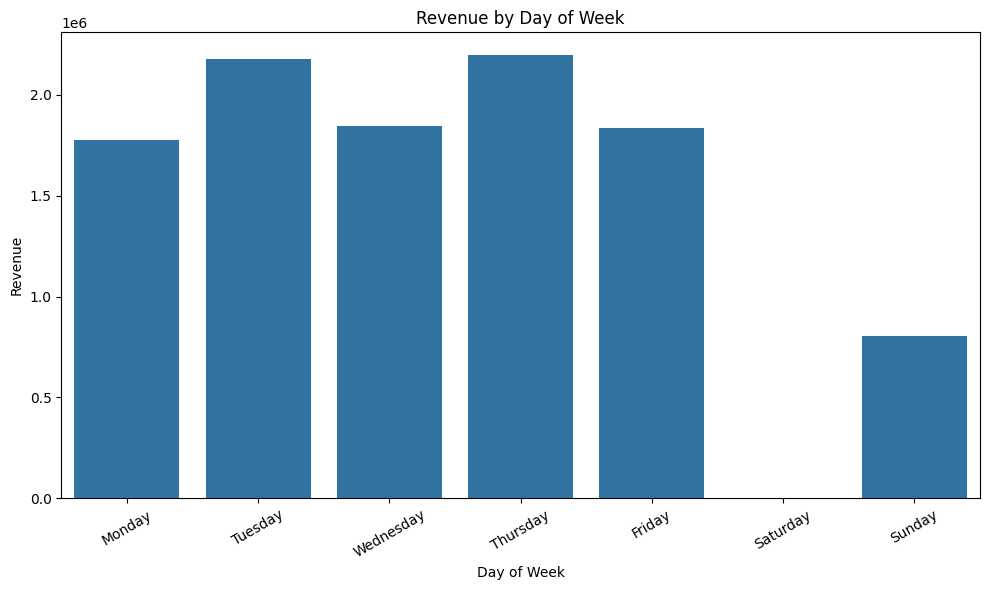

In [23]:
# ── Section 6.9: Sales by Day of Week ──────────────────────────────────────

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = (
    df_sales
    .groupby("DayOfWeek", as_index=False)["Revenue"]
    .sum()
)

weekday_sales["DayOfWeek"] = pd.Categorical(
    weekday_sales["DayOfWeek"],
    categories=day_order,
    ordered=True
)

weekday_sales = weekday_sales.sort_values("DayOfWeek")

plt.figure(figsize=(10, 6))

sns.barplot(
    data=weekday_sales,
    x="DayOfWeek",
    y="Revenue"
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 6.10 Revenue Distribution

The distribution of transaction-level revenue is analyzed to understand the typical revenue range and identify highly skewed or unusually large transaction values.

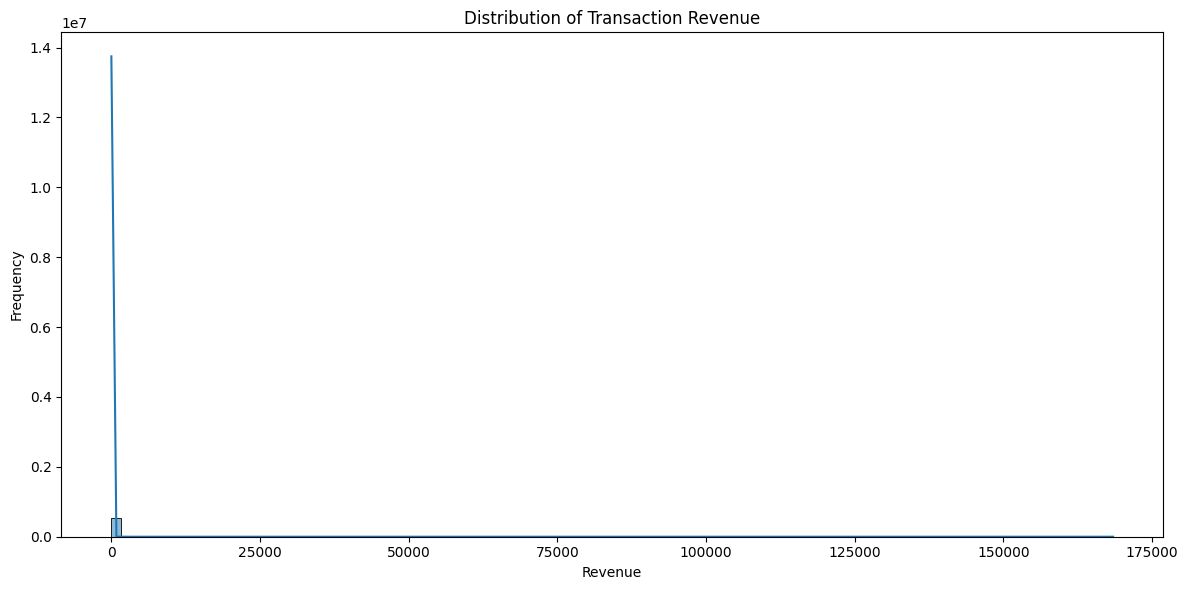

In [24]:
# ── Section 6.10: Revenue Distribution ────────────────────────────────────

plt.figure(figsize=(12, 6))

sns.histplot(
    df_sales["Revenue"],
    bins=100,
    kde=True
)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 6.11 Revenue Summary by Country

Country-level sales performance is summarized using total revenue, number of transactions, and quantity sold. This provides a broader view of geographic sales performance.

In [25]:
# ── Section 6.11: Country-Level Sales Summary ──────────────────────────────

country_summary = (
    df_sales
    .groupby("Country", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        TransactionLines=("InvoiceNo", "count")
    )
    .sort_values("TotalRevenue", ascending=False)
)

print("Top 10 countries by revenue:")
country_summary.head(10)

Top 10 countries by revenue:


,Country,TotalRevenue,TotalQuantity,TransactionLines
36,United Kingdom,9001744.094,4646906,479985
24,Netherlands,285446.340,200361,2359
10,EIRE,283140.520,147007,7879
14,Germany,228678.400,119154,9025
13,France,209625.370,112060,8392
0,Australia,138453.810,83891,1181
31,Spain,61558.560,27933,2479
33,Switzerland,57067.600,30617,1958
3,Belgium,41196.340,23237,2031
32,Sweden,38367.830,36078,450


## 7. Correlation Analysis

Correlation analysis is used to examine the relationships between numerical variables in the retail sales dataset.

The analysis focuses on variables such as quantity, unit price, and revenue to identify the strength and direction of their linear relationships.

In [26]:
# ── Section 7.1: Correlation Analysis ───────────────────────────────────────

correlation_data = df_sales[
    ["Quantity", "UnitPrice", "Revenue"]
]

correlation_matrix = correlation_data.corr()

print("Correlation Matrix:")
correlation_matrix

Correlation Matrix:


,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
Revenue,0.907402,0.137381,1.000000


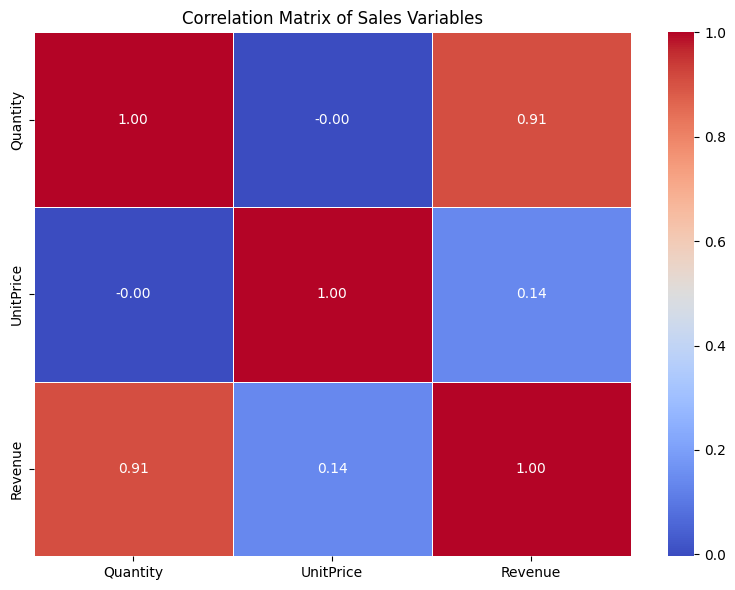

In [27]:
# ── Section 7.2: Correlation Heatmap ───────────────────────────────────────

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Sales Variables")
plt.tight_layout()
plt.show()

## 8. Monthly Sales Performance

Monthly sales performance is summarized using total revenue, quantity sold, and transaction lines.

This analysis provides numerical evidence of changes in sales activity across the study period.

In [28]:
# ── Section 8.1: Monthly Sales Performance ─────────────────────────────────

monthly_performance = (
    df_sales
    .groupby(["Year", "Month"], as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        TransactionLines=("InvoiceNo", "count")
    )
)

monthly_performance["YearMonth"] = pd.to_datetime(
    monthly_performance["Year"].astype(str) + "-" +
    monthly_performance["Month"].astype(str) + "-01"
)

monthly_performance = (
    monthly_performance
    .sort_values("YearMonth")
    .reset_index(drop=True)
)

print("Monthly Sales Performance:")
monthly_performance[
    ["YearMonth", "TotalRevenue", "TotalQuantity", "TransactionLines"]
]

Monthly Sales Performance:


,YearMonth,TotalRevenue,TotalQuantity,TransactionLines
0,2010-12-01,821452.730,358019,40991
1,2011-01-01,689811.610,387099,34060
2,2011-02-01,522545.560,282934,26882
3,2011-03-01,716215.260,376599,35497
4,2011-04-01,536968.491,307953,28882
5,2011-05-01,769296.610,395001,35917
6,2011-06-01,760547.010,388511,35716
7,2011-07-01,718076.121,399693,38395
8,2011-08-01,757841.380,421020,34264
9,2011-09-01,1056435.192,569573,48900


In [29]:
# ── Section 8.2: Highest and Lowest Revenue Months ─────────────────────────

highest_revenue_month = monthly_performance.loc[
    monthly_performance["TotalRevenue"].idxmax()
]

lowest_revenue_month = monthly_performance.loc[
    monthly_performance["TotalRevenue"].idxmin()
]

print("Highest revenue month:")
print(highest_revenue_month)

print("\nLowest revenue month:")
print(lowest_revenue_month)

Highest revenue month:
Year                               2011
Month                                11
TotalRevenue                 1503866.78
TotalQuantity                    751377
TransactionLines                  82004
YearMonth           2011-11-01 00:00:00
Name: 11, dtype: object

Lowest revenue month:
Year                               2011
Month                                 2
TotalRevenue                  522545.56
TotalQuantity                    282934
TransactionLines                  26882
YearMonth           2011-02-01 00:00:00
Name: 2, dtype: object


## 9. Customer Purchasing Analysis

Customer purchasing behavior is analyzed using transactions with available CustomerID values.

The analysis examines the number of unique customers, total revenue generated by identified customers, and the distribution of customer purchasing activity.

In [30]:
# ── Section 9.1: Customer Purchasing Summary ───────────────────────────────

customer_data = df_sales.dropna(subset=["CustomerID"]).copy()

customer_summary = (
    customer_data
    .groupby("CustomerID", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        TransactionLines=("InvoiceNo", "count")
    )
)

print(f"Number of identified customers: {customer_summary['CustomerID'].nunique():,}")

print(f"Total revenue from identified customers: "
      f"{customer_summary['TotalRevenue'].sum():,.2f}")

print("\nCustomer purchasing summary:")
customer_summary.describe()

Number of identified customers: 4,338
Total revenue from identified customers: 8,887,208.89

Customer purchasing summary:


,CustomerID,TotalRevenue,TotalQuantity,TransactionLines
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,2048.688081,1187.644537,90.523744
std,1721.808492,8985.230220,5043.619654,225.506968
min,12346.000000,3.750000,1.000000,1.000000
25%,13813.250000,306.482500,159.000000,17.000000
50%,15299.500000,668.570000,378.000000,41.000000
75%,16778.750000,1660.597500,989.750000,98.000000
max,18287.000000,280206.020000,196915.000000,7676.000000


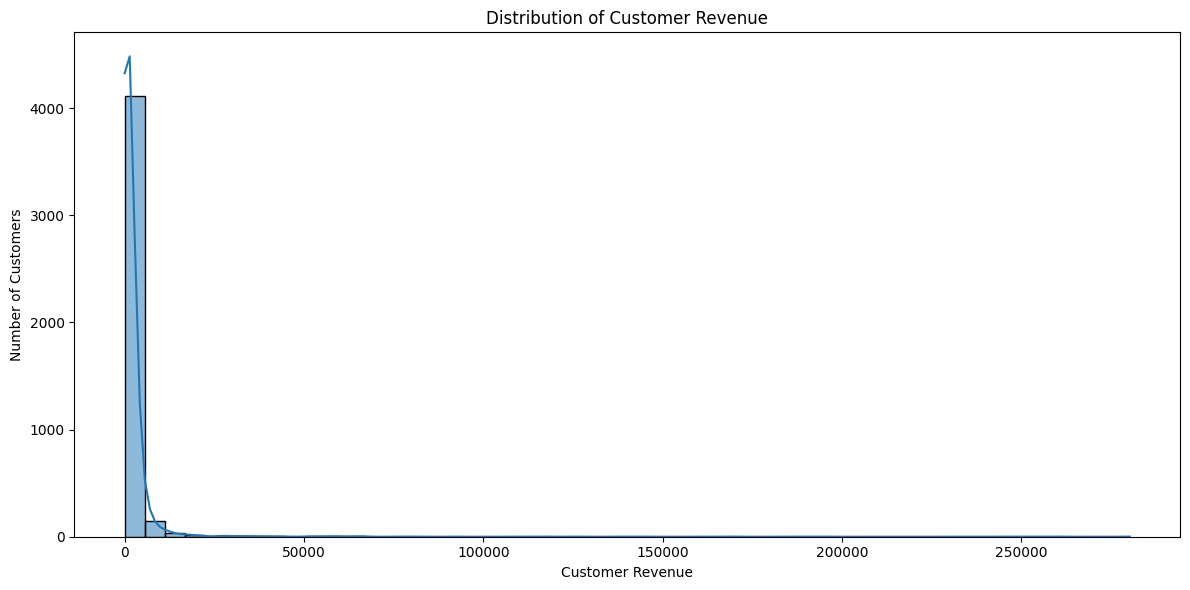

In [31]:
# ── Section 9.2: Customer Revenue Distribution ─────────────────────────────

plt.figure(figsize=(12, 6))

sns.histplot(
    customer_summary["TotalRevenue"],
    bins=50,
    kde=True
)

plt.title("Distribution of Customer Revenue")
plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

## 10. Product Performance Analysis

Product performance is analyzed using total revenue, total quantity sold, and transaction-line frequency.

This analysis helps identify products with high sales volume and products that contribute strongly to overall revenue.

In [32]:
# ── Section 10.1: Product Performance Summary ──────────────────────────────

product_summary = (
    df_sales
    .groupby("Description", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        TransactionLines=("InvoiceNo", "count")
    )
    .sort_values("TotalRevenue", ascending=False)
)

print("Top 10 products by revenue:")
product_summary.head(10)

Top 10 products by revenue:


,Description,TotalRevenue,TotalQuantity,TransactionLines
1067,DOTCOM POSTAGE,206248.77,706,706
2853,REGENCY CAKESTAND 3 TIER,174156.54,13851,2007
2387,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3844,WHITE HANGING HEART T-LIGHT HOLDER,106236.72,37872,2311
2413,PARTY BUNTING,99445.23,18283,1699
1816,JUMBO BAG RED RETROSPOT,94159.81,48371,2109
2052,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,250
2692,POSTAGE,78101.88,3150,1126
2192,Manual,77752.82,6985,317
2741,RABBIT NIGHT LIGHT,66870.03,30739,1017


In [33]:
# ── Section 10.2: Top Products by Quantity ─────────────────────────────────

print("Top 10 products by quantity sold:")
product_summary.sort_values(
    "TotalQuantity",
    ascending=False
).head(10)

Top 10 products by quantity sold:


,Description,TotalRevenue,TotalQuantity,TransactionLines
2387,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
2052,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,250
3934,WORLD WAR 2 GLIDERS ASSTD DESIGNS,13814.01,54951,536
1816,JUMBO BAG RED RETROSPOT,94159.81,48371,2109
3844,WHITE HANGING HEART T-LIGHT HOLDER,106236.72,37872,2311
2681,POPCORN HOLDER,34288.67,36749,825
2337,PACK OF 72 RETROSPOT CAKE CASES,21246.45,36396,1352
227,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1476
2741,RABBIT NIGHT LIGHT,66870.03,30739,1017
2107,MINI PAINT SET VINTAGE,16937.82,26633,380


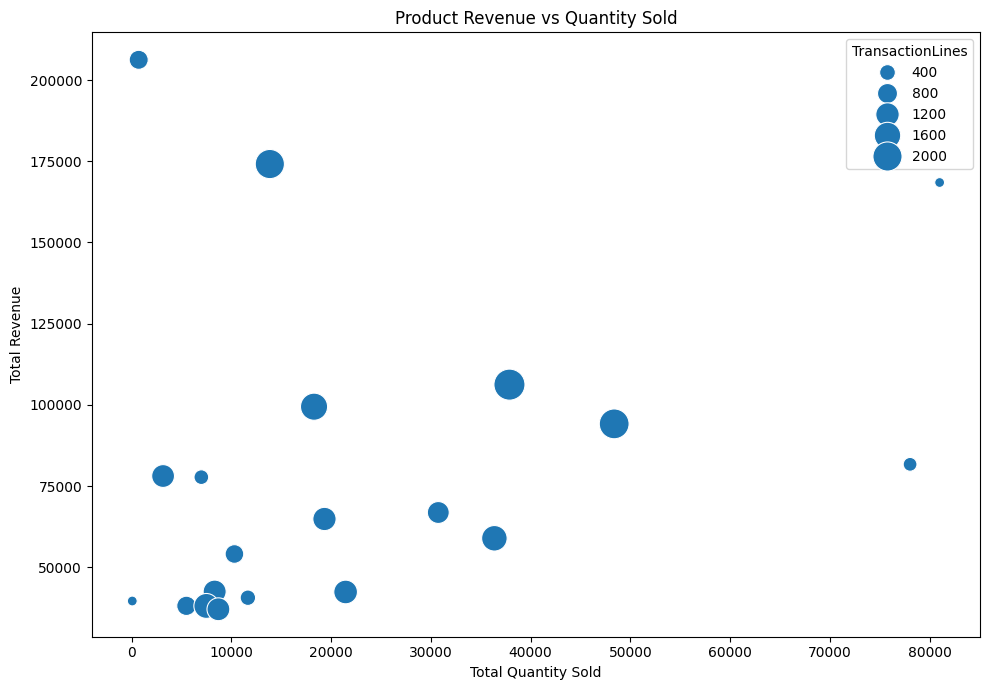

In [34]:
# ── Section 10.3: Product Revenue vs Quantity ──────────────────────────────

top_products = product_summary.head(20)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=top_products,
    x="TotalQuantity",
    y="TotalRevenue",
    size="TransactionLines",
    sizes=(50, 500)
)

plt.title("Product Revenue vs Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

## 11. Outlier and Data Quality Analysis

Outlier analysis is performed to identify unusually large transaction quantities and revenue values that may strongly influence the overall sales results.

Potential outliers are examined separately before drawing final business conclusions. No observation is removed solely because it has a large value unless there is evidence that it represents invalid data.

In [35]:
# ── Section 11.1: Largest Transaction Quantities ────────────────────────────

largest_quantity_transactions = (
    df_sales[
        [
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "UnitPrice",
            "Revenue",
            "Country"
        ]
    ]
    .sort_values("Quantity", ascending=False)
    .head(10)
)

print("Top 10 transactions by quantity:")
largest_quantity_transactions

Top 10 transactions by quantity:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00,United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00,United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92,United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00,United Kingdom
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40,United Kingdom


In [36]:
# ── Section 11.2: Largest Transaction Revenues ──────────────────────────────

largest_revenue_transactions = (
    df_sales[
        [
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "UnitPrice",
            "Revenue",
            "Country"
        ]
    ]
    .sort_values("Revenue", ascending=False)
    .head(10)
)

print("Top 10 transactions by revenue:")
largest_revenue_transactions

Top 10 transactions by revenue:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,United Kingdom
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,13541.33,13541.33,United Kingdom
299982,A563185,B,Adjust bad debt,1,11062.06,11062.06,United Kingdom
173382,551697,POST,POSTAGE,1,8142.75,8142.75,United Kingdom
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,Netherlands


In [37]:
# ── Section 11.3: Outlier Summary ──────────────────────────────────────────

quantity_q1 = df_sales["Quantity"].quantile(0.25)
quantity_q3 = df_sales["Quantity"].quantile(0.75)
quantity_iqr = quantity_q3 - quantity_q1

quantity_upper_bound = quantity_q3 + 1.5 * quantity_iqr

revenue_q1 = df_sales["Revenue"].quantile(0.25)
revenue_q3 = df_sales["Revenue"].quantile(0.75)
revenue_iqr = revenue_q3 - revenue_q1

revenue_upper_bound = revenue_q3 + 1.5 * revenue_iqr

quantity_outliers = (df_sales["Quantity"] > quantity_upper_bound).sum()
revenue_outliers = (df_sales["Revenue"] > revenue_upper_bound).sum()

print(f"Quantity upper outlier boundary: {quantity_upper_bound:,.2f}")
print(f"Number of quantity outliers: {quantity_outliers:,}")

print(f"\nRevenue upper outlier boundary: {revenue_upper_bound:,.2f}")
print(f"Number of revenue outliers: {revenue_outliers:,}")

Quantity upper outlier boundary: 26.00
Number of quantity outliers: 27,111

Revenue upper outlier boundary: 38.40
Number of revenue outliers: 42,624


## 12. Product Data Quality Check

The retail dataset contains some transaction descriptions that represent services, fees, adjustments, or administrative entries rather than physical products.

These records are identified separately so that product-performance analysis is not distorted by non-product transactions.

Large transaction quantities are also retained unless there is evidence that the underlying record is invalid.

In [38]:
# ── Section 12.1: Identify Non-Product Transaction Entries ──────────────────

non_product_descriptions = [
    "POSTAGE",
    "DOTCOM POSTAGE",
    "MANUAL",
    "CARRIAGE",
    "NEXT DAY CARRIAGE",
    "BANK CHARGES",
    "AMAZON FEE",
    "ADJUST BAD DEBT"
]

non_product_mask = (
    df_sales["Description"]
    .str.upper()
    .isin(non_product_descriptions)
)

non_product_sales = df_sales[non_product_mask].copy()

print(f"Potential non-product transaction lines: {len(non_product_sales):,}")

print("\nNon-product / service descriptions identified:")
print(non_product_sales["Description"].value_counts())

Potential non-product transaction lines: 2,384

Non-product / service descriptions identified:
Description
POSTAGE              1126
DOTCOM POSTAGE        706
Manual                317
CARRIAGE              141
Next Day Carriage      79
Bank Charges           12
AMAZON FEE              2
Adjust bad debt         1
Name: count, dtype: int64


In [39]:
# ── Section 12.2: Compare Product and Non-Product Revenue ──────────────────

non_product_revenue = non_product_sales["Revenue"].sum()
total_revenue = df_sales["Revenue"].sum()

print(f"Total revenue: {total_revenue:,.2f}")
print(f"Potential non-product revenue: {non_product_revenue:,.2f}")
print(
    f"Potential non-product revenue percentage: "
    f"{(non_product_revenue / total_revenue) * 100:.2f}%"
)

Total revenue: 10,642,110.80
Potential non-product revenue: 395,342.62
Potential non-product revenue percentage: 3.71%


In [40]:
# ── Section 12.3: Create Product-Only Dataset ───────────────────────────────

df_product_sales = df_sales[~non_product_mask].copy()

print(
    f"Product-only dataset: "
    f"{df_product_sales.shape[0]:,} rows × "
    f"{df_product_sales.shape[1]:,} columns"
)

print(
    f"Product-only revenue: "
    f"{df_product_sales['Revenue'].sum():,.2f}"
)

Product-only dataset: 522,494 rows × 15 columns
Product-only revenue: 10,246,768.18


## 13. Product Performance — Product-Only Analysis

Product performance is recalculated using the product-only dataset to exclude identified service, fee, postage, and adjustment entries from physical product rankings.

In [41]:
# ── Section 13.1: Product-Only Performance Summary ─────────────────────────

product_summary = (
    df_product_sales
    .groupby("Description", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        TransactionLines=("InvoiceNo", "count")
    )
    .sort_values("TotalRevenue", ascending=False)
)

print("Top 10 physical products by revenue:")
product_summary.head(10)

Top 10 physical products by revenue:


,Description,TotalRevenue,TotalQuantity,TransactionLines
2845,REGENCY CAKESTAND 3 TIER,174156.54,13851,2007
2380,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3836,WHITE HANGING HEART T-LIGHT HOLDER,106236.72,37872,2311
2406,PARTY BUNTING,99445.23,18283,1699
1811,JUMBO BAG RED RETROSPOT,94159.81,48371,2109
2047,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,250
2733,RABBIT NIGHT LIGHT,66870.03,30739,1017
2374,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,19329,1184
226,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1476
744,CHILLI LIGHTS,54096.36,10302,667


In [42]:
# ── Section 13.2: Top Physical Products by Quantity ────────────────────────

print("Top 10 physical products by quantity sold:")

product_summary.sort_values(
    "TotalQuantity",
    ascending=False
).head(10)

Top 10 physical products by quantity sold:


,Description,TotalRevenue,TotalQuantity,TransactionLines
2380,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
2047,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,250
3926,WORLD WAR 2 GLIDERS ASSTD DESIGNS,13814.01,54951,536
1811,JUMBO BAG RED RETROSPOT,94159.81,48371,2109
3836,WHITE HANGING HEART T-LIGHT HOLDER,106236.72,37872,2311
2674,POPCORN HOLDER,34288.67,36749,825
2330,PACK OF 72 RETROSPOT CAKE CASES,21246.45,36396,1352
226,ASSORTED COLOUR BIRD ORNAMENT,58927.62,36362,1476
2733,RABBIT NIGHT LIGHT,66870.03,30739,1017
2102,MINI PAINT SET VINTAGE,16937.82,26633,380


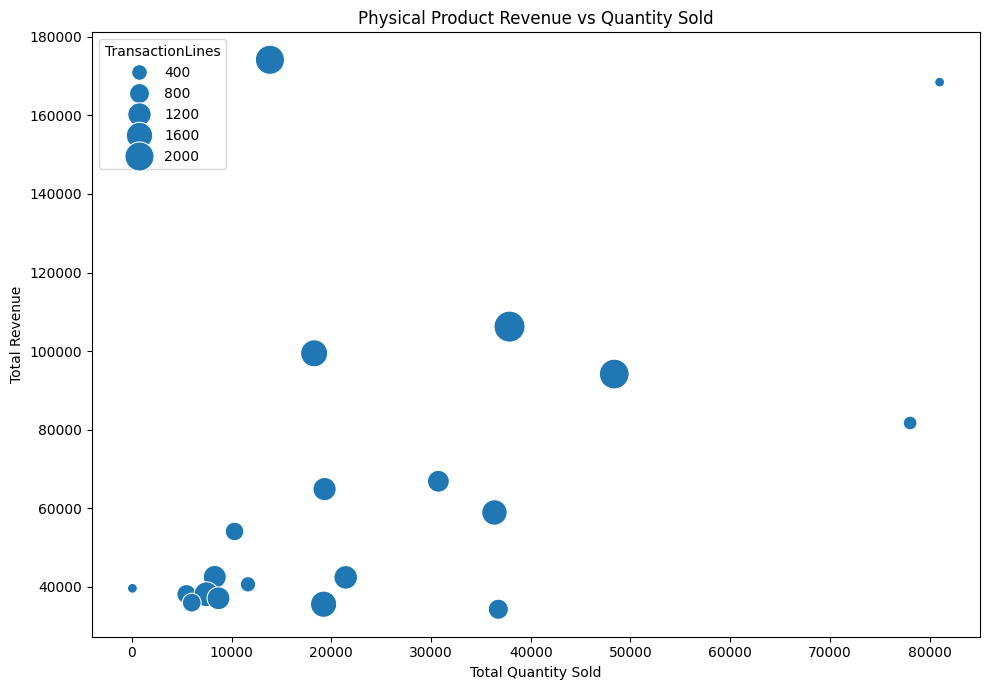

In [43]:
# ── Section 13.3: Product Revenue vs Quantity ───────────────────────────────

top_products = product_summary.head(20)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=top_products,
    x="TotalQuantity",
    y="TotalRevenue",
    size="TransactionLines",
    sizes=(50, 500)
)

plt.title("Physical Product Revenue vs Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

## 14. Key Business Metrics

Key sales metrics are calculated to provide a concise summary of the retail dataset and support the final business insights.

In [44]:
# ── Section 14.1: Key Business Metrics ─────────────────────────────────────

total_revenue = df_sales["Revenue"].sum()
total_quantity = df_sales["Quantity"].sum()
total_transaction_lines = len(df_sales)
unique_invoices = df_sales["InvoiceNo"].nunique()
unique_products = df_product_sales["Description"].nunique()
unique_countries = df_sales["Country"].nunique()
identified_customers = df_sales["CustomerID"].nunique()

print("KEY BUSINESS METRICS")
print("-" * 50)

print(f"Total Revenue:              {total_revenue:,.2f}")
print(f"Total Quantity Sold:        {total_quantity:,}")
print(f"Transaction Lines:          {total_transaction_lines:,}")
print(f"Unique Invoices:            {unique_invoices:,}")
print(f"Unique Products:            {unique_products:,}")
print(f"Countries Represented:      {unique_countries:,}")
print(f"Identified Customers:       {identified_customers:,}")

KEY BUSINESS METRICS
--------------------------------------------------
Total Revenue:              10,642,110.80
Total Quantity Sold:        5,572,420
Transaction Lines:          524,878
Unique Invoices:            19,960
Unique Products:            4,018
Countries Represented:      38
Identified Customers:       4,338


In [45]:
# ── Section 14.2: Average Transaction Metrics ──────────────────────────────

average_transaction_revenue = (
    df_sales.groupby("InvoiceNo")["Revenue"].sum().mean()
)

average_transaction_quantity = (
    df_sales.groupby("InvoiceNo")["Quantity"].sum().mean()
)

print("AVERAGE TRANSACTION METRICS")
print("-" * 50)

print(
    f"Average Revenue per Invoice: "
    f"{average_transaction_revenue:,.2f}"
)

print(
    f"Average Quantity per Invoice: "
    f"{average_transaction_quantity:,.2f}"
)

AVERAGE TRANSACTION METRICS
--------------------------------------------------
Average Revenue per Invoice: 533.17
Average Quantity per Invoice: 279.18


## 15. Business Insights and Recommendations

The analytical results provide several insights into retail sales performance, product demand, customer purchasing behavior, and geographic sales distribution.

The following insights are based on the calculated metrics and visualizations generated during the analysis.

### 15.1 Key Business Insights

#### 1. Monthly Sales Performance

Revenue varied considerably across the study period. November 2011 recorded the highest monthly revenue at 1,503,866.78, while February 2011 recorded the lowest monthly revenue at 522,545.56.

#### 2. Geographic Sales Concentration

The United Kingdom generated the largest share of revenue in the dataset, with approximately 9.00 million in total revenue. Other countries such as the Netherlands, EIRE, Germany, and France contributed substantially smaller amounts.

#### 3. Product Revenue Performance

REGENCY CAKESTAND 3 TIER generated the highest revenue among the physical products analyzed, with total revenue of 174,156.54.

#### 4. Product Sales Volume

PAPER CRAFT, LITTLE BIRDIE recorded the highest total quantity sold at 80,995 units. However, this quantity came from a single transaction line, so it should be interpreted as an unusually large transaction rather than evidence of repeated purchasing activity.

#### 5. Customer Purchasing Behavior

The dataset contains 4,338 customers with identifiable CustomerID values. Customer revenue is strongly right-skewed, indicating substantial variation in total revenue generated by individual customers.

#### 6. Relationship Between Quantity and Revenue

Quantity and revenue showed a strong positive correlation of approximately 0.91, while UnitPrice and Revenue showed a weaker positive correlation of approximately 0.14.

#### 7. Non-Product Transactions

Approximately 3.71% of total revenue was associated with identified non-product or service-related entries such as postage, manual entries, carriage, bank charges, and fees. These entries were separated from the physical-product analysis.

#### 8. Revenue Distribution

Transaction-level revenue is strongly right-skewed. Most transaction lines generate relatively small amounts of revenue, while a smaller number of transactions generate substantially higher values.

### 15.2 Business Recommendations

Based on the analytical findings, the following areas can be considered for business planning:

- Monitor monthly sales patterns and investigate factors associated with high-revenue periods.
- Review product-level revenue and quantity metrics together rather than relying on a single metric.
- Investigate unusually large transactions separately from regular purchasing patterns.
- Maintain separate reporting categories for physical products, fees, postage, and administrative transactions.
- Analyze customer purchasing frequency and revenue contribution to understand differences in customer activity.
- Examine geographic sales concentration when evaluating market expansion and regional sales strategies.
- Use transaction-level and product-level dashboards to continuously monitor revenue, quantity, and sales trends.

## 16. Conclusion

This project analyzed retail transaction data to understand sales performance, product demand, customer purchasing behavior, geographic distribution, and sales trends.

The analysis showed that total revenue across the valid sales transactions was 10,642,110.80, with 5,572,420 units sold across 19,960 unique invoices and 4,018 physical products represented across 38 countries.

Monthly analysis showed considerable variation in sales performance, with November 2011 recording the highest monthly revenue and February 2011 recording the lowest.

Product-level analysis identified differences between revenue performance and sales volume. Customer-level analysis showed substantial variation in revenue contribution across identified customers, while country-level analysis demonstrated a strong concentration of sales in the United Kingdom.

Correlation analysis showed a strong positive relationship between quantity and revenue. The analysis also identified highly skewed transaction and customer revenue distributions, as well as unusually large transactions that require careful interpretation.

Overall, the project demonstrates how data cleaning, exploratory analysis, statistical analysis, and visualization can transform raw retail transaction data into meaningful business insights.